# WiFi classification with PyTorch

Prepare the incremental NPY cache, hold out target domains and split source segments, create memory-mapped DataLoaders, and train a pooled dual CNN. Only validation selects model weights; calibration and test remain reserved for later scoring and evaluation.


In [1]:
# Set a YAML path here for interactive use; None uses experiments/baseline.yaml.
config_path = None
experiment_dir = None
project_root = None


In [2]:
from pathlib import Path
import sys
import re
import json
import numpy as np
from scipy.io import loadmat, whosmat
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset, DataLoader

PROJECT_ROOT = Path(project_root or Path.cwd()).expanduser().resolve()
if (PROJECT_ROOT / "step02_models").is_dir():
    PROJECT_ROOT = PROJECT_ROOT.parent
PYTHON_ROOT = PROJECT_ROOT / "python"
DATA_ROOT = PROJECT_ROOT / "data"
NPY_ROOT = PYTHON_ROOT / "dataset"
if str(PYTHON_ROOT) not in sys.path:
    sys.path.insert(0, str(PYTHON_ROOT))
from step01_preprocessing.standardize import standardize_time
from step00_config.loader import load_config
config = load_config(config_path)


## Experiment settings

Choose `config_path` in the first cell, or leave it as `None` for `experiments/baseline.yaml`. The command-line runner injects a saved configuration and its output directory. The runner executes the complete notebook, including scoring and evaluation. When working interactively, you choose which cells to execute.

### Data and split settings

The template is shared by all three datasets. Brackets mark the optional repeat identifier. Choose `activity`, `user`, or `position` as the target; `p1` alone is only a placeholder, not a useful position-classification problem.

Select a folder under `python/dataset/`: for crossroom use `generated_features`; for self_time/setting_dataset use the dataset directory or a compatible subset. The template matches `_time.npy`; `_stft.npy` is paired automatically.

`data.datasets` in YAML accepts one or several directories relative to `python/dataset/` (or absolute cache paths); these become `data_config["roots"]`. Overlapping roots are deduplicated by resolved file path. All selected files must have matching feature shapes. Roots are pooled before stratified splitting; this is not a train-on-one-dataset/test-on-another protocol. The default uses crossroom/generated_features. `doc` is the shared label for document activity.


In [3]:
from step00_config.schema import InferenceConfig
inference_batch_size = InferenceConfig(**config["inference"]).batch_size

data_config = {
    "domain_key": config["data"]["domain_key"],
    "roots": [NPY_ROOT / folder for folder in config["data"]["datasets"]],
    "filename_template": config["data"]["filename_template"],
    "task": config["data"]["task"],
}
split_seed = config["split_seed"]
training_seed = config["training_seed"]
split_config = config["split"].copy()
prepare_npy_cache = config["prepare_npy_cache"]
print(json.dumps(config, indent=2))


{
  "split_seed": 42,
  "training_seed": 42,
  "prepare_npy_cache": false,
  "data": {
    "datasets": [
      "crossroom"
    ],
    "filename_template": "{user}_{activity}_{position}[_r{recording}]_time.npy",
    "task": "activity",
    "domain_key": "user"
  },
  "split": {
    "mode": "domain_holdout",
    "test_domains": [
      "cong"
    ],
    "validation_fraction": 0.1,
    "calibration_fraction": 0.2,
    "test_fraction": 0.2
  },
  "model": {
    "kind": "cnn_transformer",
    "embedding_dim": 32,
    "stft_frequency_bins": 64
  },
  "encoder_task": {
    "task": {
      "enabled": true,
      "weight": 1
    },
    "contrastive": {
      "enabled": true,
      "weight": 0.5,
      "temperature": 0.05
    },
    "adversarial": {
      "enabled": true,
      "conditional": true,
      "max_weight": 0.2,
      "warmup_epochs": 10,
      "hidden_dim": 128,
      "steps_per_batch": 5,
      "optimizer": "sgd",
      "learning_rate": 0.001,
      "weight_decay": 0.0001,
      "op

### Model and training settings

Edit `model`, `training` (including `training.scheduler`), `augmentation`, `sampling`, `encoder_task`, `encoder_background`, and `decoder` in the YAML file. These objects are created before DataLoaders and the model. For interactive experiments, you can also edit their attributes here. `training.optimizer_kwargs` passes optimizer-specific arguments such as SGD momentum.

`split_seed` fixes data splits and scorer CV folds; `training_seed` controls initialization, shuffle, Dropout and the independent augmentation RNG. The YAML selects which components are enabled. Cosine uses the epoch budget by default; plateau monitors validation loss. Give early stopping enough patience for a reduced learning rate to take effect.

Augmentation runs only on training batches. The master `augmentation.enabled` switch controls the whole component; `time_noise.enabled`, `time_mask.enabled`, and `stft_mask.enabled` select any combination. Gaussian/uniform noise is added to standardized time features; time masking then zeros a short interval across all rows/groups. STFT masks operate on reconstructed time/frequency axes. Time and STFT masks are sampled independently. `frequency_bins` is 32 for setting_dataset/self_time and 64 for crossroom. New noise and bands are sampled each call; the RNG is seeded once per training setup, not per epoch. No crops or shifts are applied.


`encoder_background.enabled` adds a separately initialized background encoder shared across source domains.
Each background objective has its own switch. Task CE/CL/domain adversarial are configured under encoder_task. Task CE has independent enabled/weight controls; raw training and validation CE remain reported. train_objective_loss records the combined weighted training objective.
Reconstruction targets the model inputs (standardized time, signed-log STFT), not raw CSI.
Background activity-head fitting and all encoder/decoder updates occur only in the training loop.


In [4]:
from dataclasses import asdict
from step02_models.build import build_model
from step00_config.schema import ModelConfig, TrainingConfig, SchedulerConfig, AugmentationConfig, AdversarialConfig, ContrastiveConfig, SamplingConfig
from step03_training.monitoring import TrainingMonitor

from step00_config.schema import EncoderTaskConfig
encoder_task_config = EncoderTaskConfig(**config["encoder_task"])
model_config = ModelConfig(**config["model"])
training_config = TrainingConfig(**config["training"])
augmentation_config = AugmentationConfig(**config["augmentation"])
adversarial_config = AdversarialConfig(**encoder_task_config.adversarial)
contrastive_config = ContrastiveConfig(**encoder_task_config.contrastive)
sampling_config = SamplingConfig(**config["sampling"])

from step00_config.schema import DecoderConfig, EncoderBackgroundConfig
encoder_background_config = EncoderBackgroundConfig(**config.get("encoder_background", {}))

decoder_config = DecoderConfig(**config["decoder"])


### Monitoring settings

The YAML `monitoring` section controls W&B. Offline logs stay in the experiment directory; `enabled: false` disables monitoring. Gradient summaries are sampled, and full activations are never saved.


In [5]:
monitor_config = config["monitoring"].copy()


## Optional: prepare the NPY cache

Set `prepare_npy_cache: true` in YAML when MAT features are added or replaced. The conversion remains fully expanded here; with the flag off, this cell does not scan or write the cache. It scans `data/` for `*_raw.mat`, excludes Archive/MergeOriginals, and mirrors relative folders under `python/dataset/`. Each recording produces `<user>_<activity>_<position>[_rNN]_time.npy` and `_stft.npy` as float32 arrays in the original `[N,270,T,3]` order. Labels stay in the filename; no normalization is applied here.

A small JSON completion record tracks source size/mtime and output sizes. Unchanged, complete pairs are skipped; missing outputs or changed source files are rebuilt. A partial conversion has no valid completion record and is retried. Source MAT files are retained. Memory holds one MAT variable at a time; no dataset-wide concatenation is performed. NPY files are uncompressed and require additional disk space.

The following cells use this cache directly through memory mapping. When no source files have changed, you can skip this conversion cell.


In [6]:
converted = skipped = 0
sources = sorted(DATA_ROOT.rglob("*_raw.mat")) if prepare_npy_cache else []
for source in sources:
    relative = source.relative_to(DATA_ROOT)
    if {part.lower() for part in relative.parts} & {"archive", "mergeoriginals"}:
        continue
    folder = NPY_ROOT / relative.parent
    folder.mkdir(parents=True, exist_ok=True)
    stem = source.stem.removesuffix("_raw")
    outputs = {"segment_data": folder / f"{stem}_time.npy",
               "segment_data_stft": folder / f"{stem}_stft.npy"}
    marker = folder / f"{stem}_cache.json"
    stat = source.stat()
    signature = {"version": 1, "source": relative.as_posix(),
                 "source_bytes": stat.st_size, "source_mtime_ns": stat.st_mtime_ns}
    previous = {}
    if marker.exists():
        try:
            previous = json.loads(marker.read_text())
        except (ValueError, OSError):
            pass  # An incomplete completion record is rebuilt.
    if (previous.get("source_info") == signature
            and all(path.is_file() and path.stat().st_size == previous.get("output_bytes", {}).get(key)
                    for key, path in outputs.items())):
        skipped += 1
        continue

    shapes = {name: shape for name, shape, _ in whosmat(source)}
    a, b = shapes["segment_data"], shapes["segment_data_stft"]
    if (len(a) != 4 or len(b) != 4 or a[0] != b[0]
            or a[1::2] != (270, 3) or b[1::2] != (270, 3)):
        raise ValueError(f"Expected paired [N,270,T,3] arrays: {source}")
    marker.unlink(missing_ok=True)
    print(f"Converting: {relative}")
    for variable, destination in outputs.items():
        # Read one variable and cast one segment at a time to limit peak RAM.
        array = loadmat(source, variable_names=[variable])[variable]
        temporary = destination.with_suffix(".tmp.npy")
        mapped = np.lib.format.open_memmap(
            temporary, mode="w+", dtype=np.float32, shape=array.shape,
        )
        try:
            for i in range(len(array)):
                mapped[i] = array[i]
                if not np.isfinite(mapped[i]).all():
                    raise ValueError(f"Nonfinite float32 features: {source}, {variable}, segment {i}")
            mapped.flush()
        finally:
            del mapped, array
        temporary.replace(destination)
    current = source.stat()
    if (current.st_size, current.st_mtime_ns) != (stat.st_size, stat.st_mtime_ns):
        raise RuntimeError(f"Source changed during conversion; rerun this cell: {source}")
    completed = {"source_info": signature,
                 "output_bytes": {key: path.stat().st_size for key, path in outputs.items()}}
    temporary_marker = marker.with_suffix(".tmp.json")
    temporary_marker.write_text(json.dumps(completed, indent=2))
    temporary_marker.replace(marker)
    converted += 1

if prepare_npy_cache:
    print(f"NPY cache: {converted} converted, {skipped} skipped. Output: {NPY_ROOT}")
else:
    print("Using the existing NPY cache; conversion is disabled.")


Using the existing NPY cache; conversion is disabled.


## Find NPY pairs and read labels

Scan `_time.npy` filenames and pair each with `_stft.npy`. Completion records and NPY headers verify paired shapes without loading the full arrays. `metadata` retains all filename fields. Archive and MergeOriginals are excluded.

In [7]:
parts = []
for token in re.split(r"(\{[^{}]+\}|\[|\])", data_config["filename_template"]):
    if token.startswith("{"):
        parts.append(fr"(?P<{token[1:-1]}>[^_/\\]+?)")
    elif token == "[":
        parts.append("(?:")
    elif token == "]":
        parts.append(")?")
    else:
        parts.append(re.escape(token))
pattern = re.compile("".join(parts))

files, stft_files, metadata, counts, shapes = [], [], [], [], []
paths = set()
for root in data_config["roots"]:
    root = Path(root).expanduser().resolve()
    if not root.is_dir():
        raise FileNotFoundError(root)
    for path in root.rglob("*_time.npy"):
        if {p.lower() for p in path.relative_to(root).parts} & {"archive", "mergeoriginals"}:
            continue
        paths.add(path.resolve())  # Parent/child or repeated roots must not duplicate samples.

for path in sorted(paths):
    match = pattern.fullmatch(path.name)
    if match is None:
        raise ValueError(f"Filename does not match template: {path}")
    fields = {k: v for k, v in match.groupdict().items() if v is not None}
    stem = path.name.removesuffix("_time.npy")
    stft_path = path.with_name(stem + "_stft.npy")
    marker = path.with_name(stem + "_cache.json")
    if not stft_path.is_file() or not marker.is_file():
        raise ValueError(f"Incomplete NPY pair; rerun the conversion cell: {path}")
    completed = json.loads(marker.read_text())
    if (path.stat().st_size != completed["output_bytes"]["segment_data"]
            or stft_path.stat().st_size != completed["output_bytes"]["segment_data_stft"]):
        raise ValueError(f"Incomplete NPY output; rerun the conversion cell: {path}")
    time = np.load(path, mmap_mode="r")
    stft = np.load(stft_path, mmap_mode="r")
    time_shape, stft_shape = time.shape, stft.shape
    if time.dtype != np.float32 or stft.dtype != np.float32:
        raise ValueError(f"Expected float32 cache: {path}")
    del time, stft
    if (len(time_shape) != 4 or len(stft_shape) != 4
            or time_shape[0] != stft_shape[0]
            or time_shape[1::2] != (270, 3) or stft_shape[1::2] != (270, 3)):
        raise ValueError(f"Expected paired [N,270,T,3] arrays: {path}")
    if time_shape[0] == 0:
        continue
    files.append(path)
    stft_files.append(stft_path)
    metadata.append(fields)
    counts.append(time_shape[0])
    shapes.append((time_shape[1:], stft_shape[1:]))

if not files or len(set(shapes)) != 1:
    raise ValueError("Select a nonempty dataset with consistent feature shapes")
labels = np.array([m[data_config["task"]] for m in metadata])
counts = np.array(counts)
time_shape, stft_shape = shapes[0]
size_gib = counts.sum() * (np.prod(time_shape) + np.prod(stft_shape)) * 4 / 1024**3
print(f"{len(files)} files, {counts.sum()} segments, {len(set(labels))} labels")
print(f"NPY arrays on disk: {size_gib:.2f} GiB; accessed through memory mapping")


125 files, 4273 segments, 5 labels
NPY arrays on disk: 105.21 GiB; accessed through memory mapping


## Split source and target data

`domain_holdout` reserves every segment of recordings matching `split.test_domains` for test. Source recordings are expanded into `(file_index, segment_index)` pairs, then shuffled and split within each prediction label into training, validation and calibration. Fractions apply to source segments per class, rounded down with at least one validation/calibration segment each. Signal arrays remain on disk.

Source subsets may share recordings, but never the same segment. The target domain never enters any source subset. `test_fraction` is unused in this mode. The default predicts activities with user `cong` held out in crossroom.

`random` retains the original four-way recording split. Training defines the label vocabulary; unseen held-out labels are rejected. Inspect the printed domain/class counts. File counts in source subsets need not sum to the dataset file count when splitting segments.

Weighted CP estimates the target/source ratio from unlabeled test inputs. No extra domains are reserved. Target labels never enter ratio fitting.


In [8]:
from collections import Counter
from step00_config.schema import WeightingConfig

weighting_settings = WeightingConfig(**globals().get("config", {}).get("weighting", {}))
indices = np.arange(len(files))
mode = split_config["mode"]
if mode == "domain_holdout":
    domain_key = data_config["domain_key"]
    test_domains = split_config["test_domains"]
    if domain_key == data_config["task"]:
        raise ValueError("Domain must differ from the prediction task; held-out classes are not supported")
    if not isinstance(test_domains, list) or not test_domains:
        raise ValueError("Choose a nonempty list of test_domains")
    if not all(domain_key in m for m in metadata):
        raise ValueError(f"Filename metadata does not contain domain field: {domain_key}")
    domains = np.array([m[domain_key] for m in metadata])
    missing = set(test_domains) - set(domains)
    if missing:
        raise ValueError(f"Test domains not found: {sorted(missing)}")
    held_out = np.isin(domains, test_domains)
    source_mask = ~held_out
    source_idx, test_idx = indices[source_mask], indices[held_out]
    if not len(source_idx):
        raise ValueError("The held-out domains leave no source recordings")
else:
    if mode != "random":
        raise ValueError(f"Unknown split mode: {mode}")
    source_idx = indices

fractions = [split_config["validation_fraction"], split_config["calibration_fraction"]]
if mode == "random":
    fractions.append(split_config["test_fraction"])
if not all(0 < f < 1 for f in fractions) or sum(fractions) >= 1:
    raise ValueError("Use positive held-out fractions with a sum below one")
if mode == "domain_holdout":
    # Split lightweight segment indices; the signal arrays stay on disk.
    samples = np.array([(i, j) for i, count in enumerate(counts) for j in range(count)], dtype=int)
    source_samples = samples[source_mask[samples[:, 0]]]
    test_samples = samples[held_out[samples[:, 0]]]
    source_labels = labels[source_samples[:, 0]]
    rng = np.random.default_rng(split_seed)
    train_idx, val_idx, cal_idx = [], [], []
    for label in sorted(set(source_labels)):
        group = rng.permutation(np.flatnonzero(source_labels == label))
        n_val = max(1, int(len(group) * fractions[0]))
        n_cal = max(1, int(len(group) * fractions[1]))
        if n_val + n_cal >= len(group):
            raise ValueError(f"Source label {label!r} has too few segments for train/validation/calibration")
        val_idx.extend(group[:n_val])
        cal_idx.extend(group[n_val:n_val + n_cal])
        train_idx.extend(group[n_val + n_cal:])
    split_samples = {"train": source_samples[train_idx], "validation": source_samples[val_idx],
                     "calibration": source_samples[cal_idx], "test": test_samples}
else:
    n_classes = len(set(labels))
    n_val, n_cal, n_test = [max(n_classes, int(len(files) * f)) for f in fractions]
    train_idx, remaining = train_test_split(
        indices, test_size=n_val + n_cal + n_test,
        stratify=labels, random_state=split_seed,
    )
    val_idx, remaining = train_test_split(
        remaining, train_size=n_val,
        stratify=labels[remaining], random_state=split_seed,
    )
    cal_idx, test_idx = train_test_split(
        remaining, test_size=n_test,
        stratify=labels[remaining], random_state=split_seed,
    )
    file_splits = {"train": train_idx, "validation": val_idx,
                   "calibration": cal_idx, "test": test_idx}
    split_samples = {name: np.array([(i, j) for i in idx for j in range(counts[i])], dtype=int)
                     for name, idx in file_splits.items()}
# Source files can occur in several subsets, but individual segments cannot.
split_indices = ({name: np.unique(samples[:, 0]) for name, samples in split_samples.items()}
                 if mode == "domain_holdout" else file_splits)

# Class vocabulary comes from training, never from held-out labels.
class_names = sorted(set(labels[split_indices["train"]].tolist()))
label_map = {name: i for i, name in enumerate(class_names)}
for name, idx in split_indices.items():
    unseen = set(labels[idx]) - set(class_names)
    if unseen:
        raise ValueError(f"{name} contains labels absent from training: {sorted(unseen)}")
targets = np.array([label_map[label] for label in labels])
split_unit = "segment" if mode == "domain_holdout" else "recording"
print("Source split unit:", split_unit)
print("Label map:", label_map)
split_summary = {}
for name, idx in split_indices.items():
    summary = {"files": len(idx), "segments": len(split_samples[name]),
               "class_files": dict(sorted(Counter(labels[idx].tolist()).items())),
               "class_segments": dict(sorted(Counter(labels[split_samples[name][:, 0]].tolist()).items()))}
    if mode == "domain_holdout":
        summary["domain_files"] = dict(sorted(Counter(domains[idx].tolist()).items()))
    split_summary[name] = summary
    print(name, summary)


Source split unit: segment
Label map: {'doc': 0, 'sit': 1, 'squat': 2, 'walk': 3, 'wipe': 4}
train {'files': 115, 'segments': 2735, 'class_files': {'doc': 25, 'sit': 23, 'squat': 23, 'walk': 22, 'wipe': 22}, 'class_segments': {'doc': 575, 'sit': 503, 'squat': 545, 'walk': 540, 'wipe': 572}, 'domain_files': {'bin': 14, 'changming': 15, 'kailong': 15, 'linqi': 15, 'runtian': 14, 'tianfang': 12, 'wenjin': 15, 'xin': 5, 'yilin': 10}}
validation {'files': 110, 'segments': 387, 'class_files': {'doc': 22, 'sit': 22, 'squat': 23, 'walk': 21, 'wipe': 22}, 'class_segments': {'doc': 82, 'sit': 71, 'squat': 77, 'walk': 76, 'wipe': 81}, 'domain_files': {'bin': 13, 'changming': 15, 'kailong': 15, 'linqi': 15, 'runtian': 14, 'tianfang': 9, 'wenjin': 15, 'xin': 5, 'yilin': 9}}
calibration {'files': 112, 'segments': 778, 'class_files': {'doc': 24, 'sit': 22, 'squat': 22, 'walk': 22, 'wipe': 22}, 'class_segments': {'doc': 164, 'sit': 143, 'squat': 155, 'walk': 153, 'wipe': 163}, 'domain_files': {'bin': 

## Create memory-mapped DataLoaders

A small Dataset in this cell maps NPY files read-only and copies only the requested segment. No full-dataset tensor or concatenation is created. The most recently accessed recording pair remains mapped; changing recordings releases that pair. OS file caching is reclaimable and is separate from allocating the complete dataset in Python.

Within each segment, the three time-domain feature groups are standardized separately across the 270 rows and time axis. The standard-deviation floor uses 270*T elements per group. STFT magnitude stays on its stored scale; no log transform or standardization is applied to STFT. Batches are `(time, stft, labels)`; when any domain-aware training component is enabled, training and validation batches additionally contain domain labels. The first three entries have shapes `[B,3,270,T]`, `[B,3,270,F_times_frames]`, `[B]`. With `sampling.enabled`, training uses full class/domain-balanced batches and its configured batch size; small groups may be oversampled. Otherwise training shuffles using `training.batch_size`, retaining singleton tail batches with batch-independent normalization. Other splits retain their original order and all samples. Start with `num_workers=0` to avoid multiprocessing/prefetch overhead on the local machine.

In [9]:
# The vocabulary comes from training only; validation labels are used for diagnostics.
domain_names, domain_targets = [], None
if adversarial_config.enabled or contrastive_config.enabled or sampling_config.enabled or encoder_background_config.enabled:
    key = data_config["domain_key"]
    if key == data_config["task"]:
        raise ValueError("Training domain must differ from the prediction task")
    training_records = split_indices["train"]
    domain_names = sorted({metadata[i][key] for i in training_records})
    if len(domain_names) < 2:
        raise ValueError("Domain-aware training requires at least two training domains")
    domain_map = {name: i for i, name in enumerate(domain_names)}
    domain_targets = np.full(len(files), -1, dtype=np.int64)
    for i in np.union1d(training_records, split_indices["validation"]):
        domain_targets[i] = domain_map.get(metadata[i][key], -1)
    print("Training domain map:", domain_map)
    if contrastive_config.enabled:
        train_files = split_samples["train"][:, 0]
        paired_classes = [label for label in np.unique(targets[train_files])
                          if len(np.unique(domain_targets[train_files][targets[train_files] == label])) >= 2]
        if not paired_classes:
            raise ValueError("Contrastive learning requires a task class in at least two training domains")
        print(f"Classes with cross-domain positives: {len(paired_classes)}/{len(class_names)}")


class NpySegments(Dataset):
    """Read one segment at a time; keep only the latest recording pair mapped."""
    def __init__(self, time_files, stft_files, labels, samples, domain_labels=None):
        self.time_files = time_files
        self.stft_files = stft_files
        self.labels = labels
        self.samples = samples
        self.domain_labels = domain_labels
        self.current_file = None
        self.time = self.stft = None

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, index):
        file_index, segment_index = self.samples[index]
        if file_index != self.current_file:
            self.time = self.stft = None
            self.time = np.load(self.time_files[file_index], mmap_mode="r")
            self.stft = np.load(self.stft_files[file_index], mmap_mode="r")
            self.current_file = file_index
        # Copy only this segment: tensors must not write into read-only NPY mappings.
        time = np.array(self.time[segment_index], copy=True)
        stft = np.array(self.stft[segment_index], copy=True)
        if not np.isfinite(time).all() or not np.isfinite(stft).all():
            raise ValueError(f"Nonfinite features: {self.time_files[file_index]}")
        time = standardize_time(time[None])[0]
        sample = (torch.from_numpy(time).permute(2, 0, 1),
                torch.from_numpy(stft).permute(2, 0, 1),
                int(self.labels[file_index]))
        return sample if self.domain_labels is None else (*sample, int(self.domain_labels[file_index]))


from step03_training.sampling import ClassDomainSampler

train_sampler = None
if sampling_config.enabled:
    train_files = split_samples["train"][:, 0]
    train_sampler = ClassDomainSampler(targets[train_files], domain_targets[train_files],
                                       train_files, sampling_config, training_seed)
    print(f"Balanced training batch size: {train_sampler.batch_size}; "
          f"sample draws per epoch: {len(train_sampler)}")

datasets, loaders = {}, {}
for name, samples in split_samples.items():
    datasets[name] = NpySegments(files, stft_files, targets, samples,
                                 domain_targets if name in ("train", "validation") else None)
    sampler = train_sampler if name == "train" else None
    batch_size = sampler.batch_size if sampler is not None else training_config.batch_size
    loaders[name] = DataLoader(
        datasets[name], batch_size=batch_size, sampler=sampler,
        shuffle=(name == "train" and sampler is None), num_workers=0,
        drop_last=False,
        generator=torch.Generator().manual_seed(training_seed),
    )
train_loader = loaders["train"]
val_loader = loaders["validation"]
print({name: len(dataset) for name, dataset in datasets.items()})


Training domain map: {'bin': 0, 'changming': 1, 'kailong': 2, 'linqi': 3, 'runtian': 4, 'tianfang': 5, 'wenjin': 6, 'xin': 7, 'yilin': 8}
Classes with cross-domain positives: 5/5
Balanced training batch size: 60; sample draws per epoch: 2760
{'train': 2735, 'validation': 387, 'calibration': 778, 'test': 373}


## Inspect a batch

Use validation here so inspecting shapes does not advance the training shuffle generator.

In [10]:
time_batch, stft_batch, label_batch = next(iter(val_loader))[:3]
print(time_batch.shape, stft_batch.shape, label_batch.shape)
print(time_batch.dtype, stft_batch.dtype, label_batch.dtype)

torch.Size([16, 3, 270, 4000]) torch.Size([16, 3, 270, 4160]) torch.Size([16])
torch.float32 torch.float32 torch.int64


## Build and inspect the selected model

`model.kind` selects the task backbone. `encoder_background.enabled` adds a shared background
encoder, optional domain/activity heads, and a decoder. Classification still uses only
the task embedding. Source users share the same background encoder; unseen target inputs
use that saved encoder without adaptation. The master switch defaults to false.

Background activity adversarial conditioning is controlled independently by `encoder_background.adversarial.conditional`. When enabled, the head receives the true training-domain one-hot; task prediction and CP do not require this condition. Conditional activity diagnostics skip unknown domains and report the evaluated sample count.

The activity adversary width is controlled independently by `encoder_background.adversarial.hidden_dim`; baseline uses 128 for both adversaries.

Both adversaries have independent optimizer/scheduler settings. `data.domain_key` is shared by both branches, CL, sampling and weighting. `decoder` controls reconstruction and shares the main optimizer. Each encoder difference loss detaches the opposite embedding; both are inactive without background.


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if (augmentation_config.enabled and augmentation_config.stft_mask["enabled"]
        and augmentation_config.stft_mask["frequency_bins"] != model_config.stft_frequency_bins):
    raise ValueError("Model and STFT masking must use the same frequency_bins")
model = build_model(model_config, time_shape, stft_shape, len(class_names), training_seed,
                      domain_classes=len(domain_names) if adversarial_config.enabled else 0,
                      domain_hidden_dim=adversarial_config.hidden_dim,
                      domain_conditional=adversarial_config.conditional,
                      encoder_background=encoder_background_config, background_domains=len(domain_names), decoder=decoder_config).to(device)
print(model)
print(f"Device: {device}; parameters: {sum(p.numel() for p in model.parameters()):,}")
# Inference smoke check; disables Dropout and does not consume training shuffle.
model.eval()
with torch.inference_mode():
    logits, embedding = model(time_batch.to(device), stft_batch.to(device), return_embedding=True)
print("Logits:", tuple(logits.shape), "Embedding:", tuple(embedding.shape))


## Train using validation only

Run experiment setup, optimizer setup, the training loop, and best-model restoration in order. Only the loop cell starts training. Validation loss selects weights and controls early stopping; calibration/test stay outside training.

Optional domain-adversarial training adds a small classifier on the shared embedding. Its domain vocabulary comes only from training records. Gradient reversal suppresses domain information in the encoder while the domain classifier minimizes cross-entropy. Its strength ramps linearly over `encoder_task.adversarial.warmup_epochs`; this is source-domain generalization, with no target-domain training. `train_loss` remains task cross-entropy; domain loss, accuracy, learning rate and reversal weight are logged separately. The domain head has its own optimizer/scheduler and performs `steps_per_batch` updates on detached embeddings before each encoder update. Validation domain metrics use clean inputs in eval mode; unknown validation domains are excluded and `validation_domain_samples` reports the count. Domain plateau scheduling uses this loss and skips epochs with no known validation domains. Low domain accuracy alone does not establish invariance.

`encoder_task.adversarial.conditional` supplies the true task-label one-hot vector only to the domain head; the encoder and task head never receive labels as inputs. `encoder_task.contrastive.enabled` adds a weighted loss on normalized embeddings, pulling same-class/different-domain pairs together and separating different classes. Same-class/same-domain pairs are excluded. It has its own switch, weight, and temperature; GRL still applies the adversarial multiplier exactly once. The contrastive loss and valid-anchor fraction are logged separately.

`sampling.enabled` supplies cross-domain pairs using class/domain-balanced training batches. All domain-aware components share `data.domain_key`. Classes missing domain combinations are retained; only anchors with cross-domain positives enter the contrastive mean. Embedding export always traverses the original split, not the balanced sampler.

Each experiment keeps one best checkpoint, a split/configuration manifest and training history. History is overwritten after each completed epoch, so interruption preserves previous epochs without accumulating epoch files. Starting a fresh reproducible run requires rerunning the DataLoader and model cells as well as training setup: the loader has its own shuffle generator.

W&B uses `monitor_config` from the settings section. Batch metrics use `train/step`; epoch metrics use `epoch`. Sampled gradients under `gradients/activations/` are dL/d(layer output), and those under `gradients/parameters/` are dL/d(parameter). Histograms contain weights and gradients, not full activation tensors. Validation does not collect diagnostics, and context cleanup removes hooks on completion or interruption.

For live dashboards, run `wandb login` in the wifi-cp environment and select online mode. Offline logs can be uploaded later with `wandb sync <offline-run-directory>`. Neither mode uploads raw CSI or checkpoints through this monitor.

W&B initialization errors stop before training. Once initialized, logging failures warn once and disable monitoring; training and local saves continue. Model errors and interrupts still propagate.


In [12]:
from datetime import datetime, timezone

run_dir = (Path(experiment_dir) if experiment_dir else
           PYTHON_ROOT / "runs" / datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%S%fZ"))
run_dir.mkdir(parents=True, exist_ok=experiment_dir is not None)
if (run_dir / "experiment.json").exists() or (run_dir / "best.pt").exists():
    raise FileExistsError(f"Existing experiment; choose a new experiment_dir: {run_dir}")
encoder_task_config = EncoderTaskConfig(task=encoder_task_config.task, difference=encoder_task_config.difference,
    contrastive=asdict(contrastive_config), adversarial=asdict(adversarial_config))
experiment = {
    "split_seed": split_seed, "training_seed": training_seed,
    "task": data_config["task"], "class_names": class_names,
    "split": split_config, "split_summary": split_summary,
    "weighting": asdict(weighting_settings),
    "label_map": label_map, "roots": [str(p) for p in data_config["roots"]],
    "time_shape": list(time_shape), "stft_shape": list(stft_shape),
    "data": {"task": data_config["task"], "domain_key": data_config["domain_key"]},
    "decoder": asdict(decoder_config),
    "model": asdict(model_config), "encoder_background": asdict(encoder_background_config),
    "training": {**asdict(training_config), "batch_size": train_loader.batch_size},
    "augmentation": asdict(augmentation_config),
    "encoder_task": asdict(encoder_task_config), "sampling": asdict(sampling_config),
    "domain_names": domain_names,
    "monitoring": monitor_config,
    "preprocessing": {"time": "per_sample_per_group_standardize", "stft": "raw_magnitude"},
    "torch_version": str(torch.__version__),
    "split_unit": split_unit,
    "recordings": [{"time": str(path.relative_to(NPY_ROOT) if path.is_relative_to(NPY_ROOT) else path),
                    "stft": str(stft_files[i].relative_to(NPY_ROOT) if stft_files[i].is_relative_to(NPY_ROOT) else stft_files[i]),
                    "label": int(targets[i]), "segments": int(counts[i]), "metadata": metadata[i]}
                   for i, path in enumerate(files)],
    "split_index_columns": ["recording_index", "segment_index"],
    "splits": {name: samples.tolist() for name, samples in split_samples.items()},
}
(run_dir / "experiment.json").write_text(json.dumps(experiment, indent=2))
# Persist interactive YAML settings even if training or CP stops early.
if not (run_dir / "config.yaml").exists():
    import yaml
    (run_dir / "config.yaml").write_text(yaml.safe_dump(config, sort_keys=False))
# Keep the full split manifest local; send experiment settings and split sizes to W&B.
monitor_experiment = {
    key: experiment[key] for key in ("split_seed", "training_seed", "augmentation",
                                    "encoder_task", "sampling", "domain_names", "encoder_background",
                                    "data", "decoder", "task", "class_names", "split", "split_unit", "split_summary",
                                    "model", "training", "time_shape", "stft_shape", "preprocessing", "torch_version")
}
monitor_experiment["split_segments"] = {name: len(ds) for name, ds in datasets.items()}


## Prepare optimizer, scheduler and augmentation

This cell initializes training state without processing batches.

In [13]:
import random
from step03_training.schedulers import build_scheduler
from step03_training.augmentation import BatchAugmenter
from step03_training.contrastive import cross_domain_contrastive
from step00_config.schema import SchedulerConfig
scheduler_config = SchedulerConfig(**training_config.scheduler)

from step00_config.schema import DecoderConfig, EncoderBackgroundConfig, EncoderTaskConfig, AdversarialConfig
from step03_training.encoder_background import joint_objective, background_validation
encoder_background_config = globals().get("encoder_background_config", EncoderBackgroundConfig())
decoder_config = globals().get("decoder_config", DecoderConfig())
# Notebook helpers can supply task CE settings while retaining typed CL/DA configs.
encoder_task_config = EncoderTaskConfig(
    task=globals().get("encoder_task_config", EncoderTaskConfig()).task,
    difference=globals().get("encoder_task_config", EncoderTaskConfig()).difference,
    contrastive=asdict(contrastive_config), adversarial=asdict(adversarial_config))
task_ce_weight = encoder_task_config.task["weight"] if encoder_task_config.task["enabled"] else 0.0
# Check settings before updating any weights.
if training_config.epochs < 1 or training_config.min_delta < 0:
    raise ValueError("Require positive epochs and nonnegative min_delta")
if training_config.patience is not None and training_config.patience < 1:
    raise ValueError("patience must be positive or None")
if training_config.learning_rate <= 0 or training_config.weight_decay < 0:
    raise ValueError("Invalid learning rate or weight decay")
if not len(train_loader) or not len(val_loader):
    raise ValueError("Training and validation must both be nonempty")
checkpoint_path = run_dir / "best.pt"

random.seed(training_seed)
np.random.seed(training_seed)
torch.manual_seed(training_seed)
model.to(device)
optimizers = {"adamw": torch.optim.AdamW, "adam": torch.optim.Adam, "sgd": torch.optim.SGD,
              "rmsprop": torch.optim.RMSprop}
main_parameters = [p for name, p in model.named_parameters()
                   if not (adversarial_config.enabled and name.startswith("domain_classifier."))
                   and not name.startswith("background_activity_classifier.")]
optimizer = optimizers[training_config.optimizer](
    main_parameters, lr=training_config.learning_rate,
    weight_decay=training_config.weight_decay,
    **training_config.optimizer_kwargs,
)
scheduler = build_scheduler(optimizer, scheduler_config, training_config.epochs)
domain_optimizer = domain_scheduler = None
if adversarial_config.enabled:
    domain_optimizer = optimizers[adversarial_config.optimizer](
        model.domain_classifier.parameters(), lr=adversarial_config.learning_rate,
        weight_decay=adversarial_config.weight_decay, **adversarial_config.optimizer_kwargs,
    )
    domain_scheduler_config = SchedulerConfig(**adversarial_config.scheduler)
    domain_scheduler = build_scheduler(domain_optimizer, domain_scheduler_config, training_config.epochs)
augmenter = BatchAugmenter(augmentation_config, training_seed, device)
criterion = torch.nn.CrossEntropyLoss()
history = []
best_loss = stopping_loss = float("inf")
best_epoch = wait = global_step = 0

background_activity_optimizer = background_activity_scheduler = None
if encoder_background_config.enabled and encoder_background_config.adversarial["enabled"]:
    background_adversarial_config = AdversarialConfig(**encoder_background_config.adversarial)
    background_activity_optimizer = optimizers[background_adversarial_config.optimizer](
        model.background_activity_classifier.parameters(),
        lr=background_adversarial_config.learning_rate,
        weight_decay=background_adversarial_config.weight_decay,
        **background_adversarial_config.optimizer_kwargs)
    background_scheduler_config = SchedulerConfig(**background_adversarial_config.scheduler)
    background_activity_scheduler = build_scheduler(
        background_activity_optimizer, background_scheduler_config, training_config.epochs)


## Train and validate

The complete batch and epoch loops are below. Run this cell to start training. W&B hooks are removed when the context exits, including on interruption.

In [14]:
# Rerun preparation with a fresh run directory before starting another experiment.
if checkpoint_path.exists():
    raise FileExistsError(f"Choose a new run directory: {run_dir}")

with TrainingMonitor(model, monitor_config, run_dir=run_dir,
                     experiment=monitor_experiment) as monitor:
    for epoch in range(1, training_config.epochs + 1):
        # 1. Train: forward -> loss -> backward -> parameter update.
        model.train()
        epoch_learning_rate = optimizer.param_groups[0]["lr"]
        domain_learning_rate = domain_optimizer.param_groups[0]["lr"] if domain_optimizer else None
        train_loss_sum = train_objective_sum = train_correct = train_count = 0
        domain_loss_sum = domain_correct = weight_sum = 0
        contrastive_loss_sum = contrastive_count = 0
        background_metric_sums = {}
        background_learning_rate = background_activity_optimizer.param_groups[0]["lr"] if background_activity_optimizer else None
        main_optimizer_updated = False
        for batch in train_loader:
            time, stft, labels = batch[:3]
            time, stft, labels = (x.to(device) for x in (time, stft, labels))
            time, stft = augmenter(time, stft)
            global_step += 1
            monitor.begin_step(global_step)
            optimizer.zero_grad(set_to_none=True)
            if adversarial_config.enabled or contrastive_config.enabled or encoder_background_config.enabled:
                logits, embedding = model(time, stft, return_embedding=True)
            else:
                logits = model(time, stft)
            task_loss = criterion(logits, labels)
            # Do not attach disabled CE: even zero gradients would trigger optimizer decay/momentum.
            loss = task_ce_weight * task_loss if task_ce_weight else logits.new_zeros(())
            batch_metrics = {}
            if contrastive_config.enabled:
                contrastive_loss, anchors = cross_domain_contrastive(
                    embedding, labels, batch[3].to(device), contrastive_config.temperature)
                loss = loss + contrastive_config.weight * contrastive_loss
                contrastive_loss_sum += contrastive_loss.item() * anchors
                contrastive_count += anchors
                batch_metrics.update({"train/contrastive_loss": contrastive_loss.item(),
                                      "train/contrastive_anchor_fraction": anchors / len(labels)})
            if adversarial_config.enabled:
                # Only the encoder gradient is reversed; the domain head minimizes CE.
                ramp_steps = adversarial_config.warmup_epochs * len(train_loader)
                weight = adversarial_config.max_weight * (min(1.0, (global_step - 1) / ramp_steps)
                                                         if ramp_steps else 1.0)
                domain_labels = batch[3].to(device)
                # Fit the domain head without updating or re-running the encoder.
                for _ in range(adversarial_config.steps_per_batch):
                    domain_optimizer.zero_grad(set_to_none=True)
                    fit_logits = model.domain_classifier(embedding.detach(), labels=labels)
                    fit_loss = criterion(fit_logits, domain_labels)
                    if not torch.isfinite(fit_loss):
                        raise ValueError("Nonfinite domain training loss")
                    fit_loss.backward()
                    domain_optimizer.step()
                # Hold the updated domain head fixed while reversing its input gradient.
                model.domain_classifier.requires_grad_(False)
                try:
                    domain_logits = model.domain_classifier(embedding, weight, labels=labels)
                finally:
                    model.domain_classifier.requires_grad_(True)
                domain_loss = criterion(domain_logits, domain_labels)
                loss = loss + domain_loss
                domain_loss_sum += domain_loss.item() * len(labels)
                domain_correct += (domain_logits.argmax(1) == domain_labels).sum().item()
                weight_sum += weight * len(labels)
                batch_metrics.update({"train/domain_loss": domain_loss.item(),
                                      "train/adversarial_weight": weight,
                                      "train/domain_learning_rate": domain_learning_rate})
            if encoder_background_config.enabled:
                background_loss, background_metrics = joint_objective(
                    model, embedding, time, stft, labels, batch[3].to(device),
                    encoder_background_config, background_activity_optimizer, global_step, len(train_loader),
                    task_difference=encoder_task_config.difference, decoder=decoder_config)
                loss = loss + background_loss
                for key, metric in background_metrics.items():
                    background_metric_sums[key] = background_metric_sums.get(key, 0.) + metric * len(labels)
                    batch_metrics["train/" + key] = metric
            if not torch.isfinite(loss):
                raise ValueError("Nonfinite training loss")
            if loss.requires_grad:
                loss.backward()
                monitor.after_backward(model)
                optimizer.step()
                main_optimizer_updated = True
            monitor.end_step({**batch_metrics, "train/batch_loss": task_loss.item(),
                              "train/objective_loss": loss.item(), "train/task_ce_weight": task_ce_weight,
                              "train/learning_rate": optimizer.param_groups[0]["lr"]})
            train_objective_sum += loss.item() * len(labels)
            train_loss_sum += task_loss.item() * len(labels)
            train_correct += (logits.argmax(1) == labels).sum().item()
            train_count += len(labels)

        # 2. Validate: no parameter updates or Dropout.
        model.eval()
        val_loss_sum = val_correct = val_count = 0
        val_domain_loss_sum = val_domain_correct = val_domain_count = 0
        background_validation_sums = {key: [0., 0, 0] for key in ("domain", "activity")}
        with torch.no_grad():
            for batch in val_loader:
                time, stft, labels = batch[:3]
                time, stft, labels = (x.to(device) for x in (time, stft, labels))
                if adversarial_config.enabled:
                    logits, embedding = model(time, stft, return_embedding=True)
                    domain_labels = batch[3].to(device)
                    known = domain_labels >= 0
                    if known.any():
                        domain_logits = model.domain_classifier(embedding[known], labels=labels[known])
                        domain_loss = criterion(domain_logits, domain_labels[known])
                        if not torch.isfinite(domain_loss):
                            raise ValueError("Nonfinite validation domain loss")
                        count = known.sum().item()
                        val_domain_loss_sum += domain_loss.item() * count
                        val_domain_correct += (domain_logits.argmax(1) == domain_labels[known]).sum().item()
                        val_domain_count += count
                else:
                    logits = model(time, stft)
                if encoder_background_config.enabled:
                    for key, (ce, correct, count) in background_validation(
                            model, time, stft, labels, batch[3].to(device)).items():
                        totals = background_validation_sums[key]
                        totals[0] += ce * count
                        totals[1] += correct
                        totals[2] += count
                loss = criterion(logits, labels)
                if not torch.isfinite(loss):
                    raise ValueError("Nonfinite validation loss")
                val_loss_sum += loss.item() * len(labels)
                val_correct += (logits.argmax(1) == labels).sum().item()
                val_count += len(labels)

        # 3. Record sample-weighted metrics.
        row = {
            "epoch": epoch,
            "learning_rate": epoch_learning_rate,
            "train_loss": train_loss_sum / train_count,
            "train_objective_loss": train_objective_sum / train_count,
            "task_ce_weight": task_ce_weight,
            "train_accuracy": train_correct / train_count,
            "train_samples": train_count,
            "validation_loss": val_loss_sum / val_count,
            "validation_accuracy": val_correct / val_count,
            "validation_samples": val_count,
        }
        if adversarial_config.enabled:
            row.update(train_domain_loss=domain_loss_sum / train_count,
                       train_domain_accuracy=domain_correct / train_count,
                       adversarial_weight=weight_sum / train_count,
                       domain_learning_rate=domain_learning_rate,
                       validation_domain_loss=val_domain_loss_sum / val_domain_count if val_domain_count else None,
                       validation_domain_accuracy=val_domain_correct / val_domain_count if val_domain_count else None,
                       validation_domain_samples=val_domain_count)
        if contrastive_config.enabled:
            row.update(train_contrastive_loss=contrastive_loss_sum / contrastive_count if contrastive_count else None,
                       train_contrastive_anchor_fraction=contrastive_count / train_count)
        row.update({"train_" + k: v / train_count for k, v in background_metric_sums.items()})
        if encoder_background_config.enabled:
            for key, (loss_sum, correct, count) in background_validation_sums.items():
                head_enabled = (encoder_background_config.domain["enabled"] if key == "domain"
                                else encoder_background_config.adversarial["enabled"])
                if head_enabled:
                    row.update({f"validation_background_{key}_loss": loss_sum / count if count else None,
                                f"validation_background_{key}_accuracy": correct / count if count else None,
                                f"validation_background_{key}_samples": count})
            if background_activity_optimizer is not None:
                row["background_activity_learning_rate"] = background_learning_rate
        history.append(row)
        value = row["validation_loss"]

        # Schedule the next epoch; history records the LR used in this epoch.
        if scheduler is not None and main_optimizer_updated:
            if scheduler_config.name == "plateau":
                scheduler.step(value)
            else:
                scheduler.step()

        if domain_scheduler is not None:
            if domain_scheduler_config.name == "plateau":
                if val_domain_count:
                    domain_scheduler.step(row["validation_domain_loss"])
            else:
                domain_scheduler.step()

        if background_activity_scheduler is not None:
            if background_scheduler_config.name == "plateau":
                if row.get("validation_background_activity_samples", 0):
                    background_activity_scheduler.step(row["validation_background_activity_loss"])
            else:
                background_activity_scheduler.step()

        # 4. Save every new absolute minimum validation loss.
        if value < best_loss:
            best_loss, best_epoch = value, epoch
            temporary = checkpoint_path.with_suffix(".pt.tmp")
            torch.save({"model_state_dict": model.state_dict(), "epoch": epoch,
                        "model_config": getattr(model, "architecture_config", None),
                        "encoder_background": asdict(encoder_background_config),
                        "decoder": asdict(decoder_config),
                        "validation_loss": value,
                        "training_config": {**asdict(training_config), "batch_size": train_loader.batch_size},
                        "split_seed": split_seed, "training_seed": training_seed,
                        "augmentation": asdict(augmentation_config),
                        "encoder_task": asdict(encoder_task_config),
                        "sampling": asdict(sampling_config),
                        "domain_names": domain_names}, temporary)
            temporary.replace(checkpoint_path)

        # 5. min_delta controls patience, not which checkpoint is best.
        if value < stopping_loss - training_config.min_delta:
            stopping_loss, wait = value, 0
        else:
            wait += 1
        # Keep completed epochs on disk even if a later epoch is interrupted.
        should_stop = training_config.patience is not None and wait >= training_config.patience
        result = {"history": history, "best_epoch": best_epoch, "best_validation_loss": best_loss,
                  "epochs_run": len(history), "stopped_early": should_stop and epoch < training_config.epochs}
        temporary = run_dir / "history.json.tmp"
        temporary.write_text(json.dumps(result, indent=2))
        temporary.replace(run_dir / "history.json")
        monitor.log_epoch(epoch, {k: v for k, v in row.items() if k != "epoch"})

        print(f"Epoch {epoch:03d} | train loss {row['train_loss']:.4f}, acc {row['train_accuracy']:.3f}"
              f" | val loss {value:.4f}, acc {row['validation_accuracy']:.3f}"
              f" | lr {epoch_learning_rate:.3g}", flush=True)
        if should_stop:
            break

    monitor.log_result(result)


wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/kailong/.netrc.


Epoch 001 | train loss 1.4784, acc 0.350 | val loss 1.2252, acc 0.416 | lr 0.01
Epoch 002 | train loss 0.9596, acc 0.634 | val loss 0.4612, acc 0.873 | lr 0.01
Epoch 003 | train loss 0.4682, acc 0.849 | val loss 0.2135, acc 0.941 | lr 0.00999
Epoch 004 | train loss 0.0416, acc 0.992 | val loss 0.1411, acc 0.961 | lr 0.00998
Epoch 005 | train loss 0.0331, acc 0.993 | val loss 0.0952, acc 0.972 | lr 0.00996
Epoch 006 | train loss 0.0065, acc 1.000 | val loss 0.1207, acc 0.969 | lr 0.00994
Epoch 007 | train loss 0.0035, acc 1.000 | val loss 0.0682, acc 0.974 | lr 0.00991
Epoch 008 | train loss 0.0018, acc 1.000 | val loss 0.0940, acc 0.977 | lr 0.00988
Epoch 009 | train loss 0.0015, acc 1.000 | val loss 0.0894, acc 0.974 | lr 0.00984
Epoch 010 | train loss 0.0055, acc 1.000 | val loss 0.1039, acc 0.969 | lr 0.0098
Epoch 011 | train loss 0.0018, acc 1.000 | val loss 0.0914, acc 0.974 | lr 0.00976
Epoch 012 | train loss 0.0023, acc 1.000 | val loss 0.0870, acc 0.966 | lr 0.00971
Epoch 013 |

## Restore the best model

History is updated after each completed epoch. Run this cell to restore the best validation checkpoint before exporting features.


In [15]:
from step03_training.cleanup import release_training_state
release_training_state(globals(), model)

# Restore the best epoch, which may differ from the final epoch.
checkpoint = torch.load(checkpoint_path, map_location="cpu", weights_only=True)
model.load_state_dict(checkpoint["model_state_dict"])
del checkpoint
model.eval()
print("Best epoch:", best_epoch, "Validation loss:", best_loss)
print("Saved to:", run_dir)


Best epoch: 66 Validation loss: 0.05825821217149496
Saved to: /home/kailong/Desktop/WiFi_Conformal_Prediction/python/runs/20261006T013602985790Z


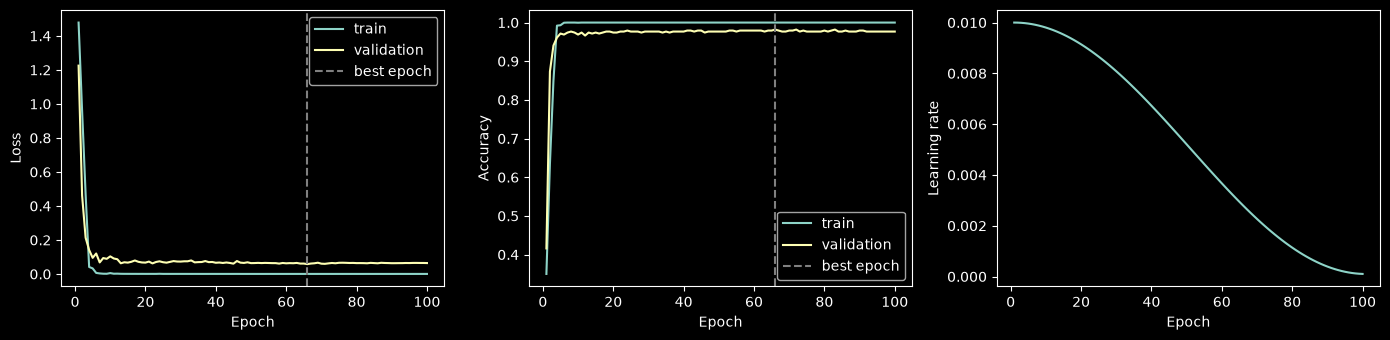

In [16]:
import matplotlib.pyplot as plt

history = result["history"]
epochs = [r["epoch"] for r in history]
fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))
for ax, metric in zip(axes, ("loss", "accuracy")):
    for split in ("train", "validation"):
        ax.plot(epochs, [r[f"{split}_{metric}"] for r in history], label=split)
    ax.axvline(result["best_epoch"], color="gray", linestyle="--", label="best epoch")
    ax.set(xlabel="Epoch", ylabel=metric.capitalize())
    ax.legend()
axes[2].plot(epochs, [r["learning_rate"] for r in history])
axes[2].set(xlabel="Epoch", ylabel="Learning rate")
fig.tight_layout()
fig.savefig(run_dir / "training.png", dpi=150)
plt.show()


## Export embeddings

The helper below exports probabilities, embeddings and labels in loader order. It uses eval mode and keeps singleton batches. All exports, including the training split, use clean inputs; augmentation is called only inside the training loop. The following cells explicitly separate training/validation, calibration and test.


In [17]:
from step06_prediction.representations import export_representations
from step00_config.schema import InferenceConfig
from step06_prediction.background import feature_representations

def representations(model, batches, device=None, inference_batch_size=None, *, include_background=False):
    """Export ordered arrays; request background to return the complete dictionary."""
    inference_batch_size = globals().get("inference_batch_size", InferenceConfig().batch_size) if inference_batch_size is None else inference_batch_size
    arrays = export_representations(model, batches, device, inference_batch_size, include_background)
    return arrays if include_background else tuple(arrays[key] for key in ("probabilities", "embeddings", "labels"))


## Fit the score model

Choose a score model and its settings here. The configured `score.kind` selects the scorer. KDE uses per-class densities on the embedding. SVM/HBGB are alternatives using probability-margin scores. All scores have shape [samples, classes]; larger values mean less conformity. Point predictions use the minimum score, not the maximum calibrated p-value.

`score.kind: softmax` directly uses `1 - p_y` from the frozen NN probabilities and skips intermediate model fitting. For pooled ordinary split CP, set `weighted_cp: false`; calibration pools all true-label scores for any score choice.

Fit KDE/SVM/HBGB only on training embeddings. Use validation accuracy to inspect/choose settings, then freeze them before running Step 06. No additional embedding normalization is applied. KDE bandwidth is in embedding units. The predeclared alpha grid below is for reporting, not selecting a threshold from test performance.
SVM probabilities use sigmoid calibration with five seeded stratified folds inside the training split (`CalibratedClassifierCV`, `ensemble=False`). Each training class needs at least five samples. This probability calibration is separate from Step 06 rank calibration.


In [18]:
# Invalidate downstream results before rerunning a prerequisite.
export_complete = score_fit_complete = calibration_complete = prediction_complete = False
from step00_config.schema import KDEConfig, SVMConfig, HBGBConfig, SoftmaxConfig, CalibrationConfig, WeightingConfig
from step04_scores.scorers import build_scorer
from step05_calibration.calibrate import RankCalibrator, WeightedRankCalibrator
from step05_calibration.weighting import DensityRatioEstimator, DomainMixtureEstimator, source_matching_weights, weight_summary
from step06_prediction.predict import prediction_sets
from step07_evaluation.evaluate import evaluate
import joblib
from datetime import datetime, timezone

score_settings = config["score"].copy()
score_kind = score_settings.pop("kind")
score_config = {"kde": KDEConfig, "svm": SVMConfig, "hbgb": HBGBConfig, "softmax": SoftmaxConfig}[score_kind](**score_settings)
calibration_config = CalibrationConfig(**config["calibration"])
alpha_grid = sorted(set([*config["alpha_grid"], calibration_config.alpha]))
if not all(0 < alpha < 1 for alpha in alpha_grid):
    raise ValueError("Every alpha must be between 0 and 1")

weighting_config = WeightingConfig(**config.get("weighting", {}))
from step06_prediction.background import feature_representations
if calibration_config.weighted_cp and weighting_config.features == "background" and not hasattr(model, "encode_background"):
    raise ValueError("Background weighting requires a saved disentangled model")

from step00_config.schema import InferenceConfig
inference_batch_size = InferenceConfig(**config["inference"]).batch_size


In [19]:
# Invalidate downstream results before rerunning a prerequisite.
export_complete = score_fit_complete = calibration_complete = prediction_complete = False
from step03_training.cleanup import release_training_state
release_training_state(globals(), model)
# Reload selected weights so every split uses the same selected model.
selected_checkpoint = torch.load(checkpoint_path, map_location="cpu", weights_only=True)
model.load_state_dict(selected_checkpoint["model_state_dict"])
model.eval()

exported = {}
for split in ("train", "validation"):
    # Training export includes the singleton tail and keeps dataset order.
    export_loader = (DataLoader(datasets[split], batch_size=train_loader.batch_size,
                                shuffle=False, num_workers=0, drop_last=False)
                     if split == "train" else loaders[split])
    exported[split] = representations(model, export_loader, include_background=True)
    labels, embeddings = exported[split]["labels"], exported[split]["embeddings"]
    print(f"{split}: {len(labels)} embeddings, shape {embeddings.shape}")

export_complete = True


train: 2735 embeddings, shape (2735, 32)
validation: 387 embeddings, shape (387, 32)


In [20]:
# Invalidate downstream results before rerunning a prerequisite.
score_fit_complete = calibration_complete = prediction_complete = False
if not globals().get("export_complete", False):
    raise ValueError("Representation export incomplete; rerun Step 05 export successfully")
if not all(torch.equal(value.detach().cpu(), selected_checkpoint["model_state_dict"][name])
           for name, value in model.state_dict().items()):
    raise ValueError("Model weights changed after export; restart Step 05 with the selected checkpoint")
if not np.array_equal(np.unique(exported["train"]["labels"]), np.arange(len(class_names))):
    raise ValueError("The scoring training split must contain every class")
scorer = build_scorer(score_config, len(class_names), seed=split_seed)
if scorer.input_key == "embeddings":
    scorer.fit(exported["train"]["embeddings"], exported["train"]["labels"])
fitted_score_config = asdict(score_config)
validation_scores = scorer.score(exported["validation"][scorer.input_key])
validation_predictions = validation_scores.argmin(axis=1)
score_validation_accuracy = float((validation_predictions == exported["validation"]["labels"]).mean())
print("Score settings:", fitted_score_config)
print(f"Scorer validation accuracy: {score_validation_accuracy:.4f}")
print(f"CNN validation accuracy: {(exported['validation']['probabilities'].argmax(1) == exported['validation']['labels']).mean():.4f}")
score_fit_complete = True


Score settings: {'kind': 'softmax'}
Scorer validation accuracy: 0.9819
CNN validation accuracy: 0.9819


## Calibrate the score model

Run this after model/score settings have been selected with validation. Calibration uses only the score of each sample's true class. Pooled calibration uses all true-label scores in one reference distribution. Ties are included, with the finite-sample +1 correction.

Each invocation creates a separate conformal result directory. Do not tune the model, scoring settings or alpha using calibration/test results. These are segment-level empirical evaluations: segments from one recording can be dependent, so file-disjoint splitting alone does not establish exchangeability of individual segments or a distribution-free coverage guarantee.

In [21]:
# Invalidate prior results before any operation that can fail during a rerun.
calibration_complete = False
prediction_complete = False
if not globals().get("score_fit_complete", False):
    raise ValueError("Score fitting incomplete or invalidated; rerun export and score fitting before calibration")
if not all(torch.equal(value.detach().cpu(), selected_checkpoint["model_state_dict"][name])
           for name, value in model.state_dict().items()):
    raise ValueError("Model weights changed after export; restart Step 05 with the selected checkpoint")
if asdict(score_config) != fitted_score_config:
    raise ValueError("Score settings changed; refit Step 05 before calibration")
frozen_calibration_config = asdict(calibration_config)
frozen_alpha_grid = list(alpha_grid)
frozen_weighting_config = asdict(weighting_config)

exported["calibration"] = representations(model, loaders["calibration"], include_background=True)
probabilities, embeddings, labels = (exported["calibration"][key] for key in ("probabilities", "embeddings", "labels"))
calibration_scores = scorer.score(exported["calibration"][scorer.input_key])
ratio_estimator = None
weight_diagnostics = {}
calibration_weights = None
if calibration_config.weighted_cp:
    # Target task labels are never supplied to the ratio estimator.
    target_loader = loaders["test"]
    source_files = split_samples["train"][:, 0]
    cal_files = split_samples["calibration"][:, 0]
    weight_domain_key = data_config["domain_key"]
    weight_domains = np.array([m[weight_domain_key] for m in metadata])
    source_strata = list(zip(weight_domains[source_files], exported["train"]["labels"]))
    cal_strata = list(zip(weight_domains[cal_files], labels))
    source_fit_weights = source_matching_weights(source_strata, cal_strata)
    target_embeddings = feature_representations(model, target_loader, microbatch_size=inference_batch_size, features=weighting_config.features)
    if weighting_config.features == "background":
        source_features = exported["train"]["background"]
        calibration_features = exported["calibration"]["background"]
    else:
        source_features = exported["train"]["embeddings"]
        calibration_features = embeddings
    if weighting_config.method == "domain_mixture":
        ratio_estimator = DomainMixtureEstimator(weighting_config, seed=split_seed).fit(
            source_features, target_embeddings, source_fit_weights, weight_domains[source_files])
    else:
        ratio_estimator = DensityRatioEstimator(weighting_config, seed=split_seed).fit(
            source_features, target_embeddings, source_fit_weights)
    calibration_weights = ratio_estimator.weights(calibration_features)
    calibrator = WeightedRankCalibrator()
    calibrator.fit(calibration_scores, labels, calibration_weights)
    weight_diagnostics = {"fit": ratio_estimator.fit_summary,
                          "calibration": weight_summary(calibration_weights),
                          "calibration_per_class": {name: weight_summary(calibration_weights[labels == i])
                                                    for i, name in enumerate(class_names) if (labels == i).any()},
                          "target_domain_segments": dict(Counter(weight_domains[split_samples["test"][:, 0]].tolist())),
                          "features": weighting_config.features, "method": weighting_config.method,
                          "weight_estimation_split": "test",
                          "clipping": {"min": weighting_config.clip_min, "max": weighting_config.clip_max},
                          "interpretation": "Unlabeled target inputs reused for estimated weights and evaluation; empirical transductive adaptation, no exact coverage guarantee."}
    print("Weight diagnostics:", weight_diagnostics)
else:
    calibrator = RankCalibrator()
    calibrator.fit(calibration_scores, labels)
calibration_counts = np.bincount(labels, minlength=len(class_names))
print("Calibration samples per class:", dict(zip(class_names, calibration_counts.tolist())))
if not calibration_config.weighted_cp:
    print("Minimum pooled p-value:", 1 / (len(calibrator.reference) + 1))

cp_dir = run_dir / ("conformal-" + datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%S%fZ"))
cp_dir.mkdir(parents=True, exist_ok=False)
import hashlib
with checkpoint_path.open("rb") as checkpoint_file:
    checkpoint_sha256 = hashlib.file_digest(checkpoint_file, "sha256").hexdigest()
cp_config = {
    "inference": {"batch_size": inference_batch_size},
    "checkpoint_sha256": checkpoint_sha256,
    "split": split_config, "weighting": frozen_weighting_config,
    "score": fitted_score_config, "calibration": frozen_calibration_config,
    "alpha_grid": frozen_alpha_grid, "class_names": list(class_names),
    "split_seed": split_seed, "training_seed": training_seed,
    "checkpoint": str(checkpoint_path.resolve()), "checkpoint_epoch": selected_checkpoint["epoch"],
    "score_validation_accuracy": score_validation_accuracy,
    "calibration_counts": calibration_counts.tolist(), "evaluation_unit": "segment",
    "split_manifest": str((run_dir / "experiment.json").resolve()),
}
(cp_dir / "config.json").write_text(json.dumps(cp_config, indent=2))
joblib.dump({"scorer": scorer, "calibrator": calibrator, "config": cp_config, "ratio_estimator": ratio_estimator}, cp_dir / "scorer_calibrator.joblib")

if ratio_estimator is not None:
    np.savez_compressed(cp_dir / "calibration_weights.npz", weights=calibration_weights,
                        source_fit_weights=source_fit_weights)
    target_samples = split_samples["test"]
    np.savez_compressed(cp_dir / "target_features.npz", embeddings=target_embeddings,
                        recording=np.array([str(files[i]) for i in target_samples[:, 0]]),
                        segment_index=target_samples[:, 1], domains=weight_domains[target_samples[:, 0]])
    (cp_dir / "weighting.json").write_text(json.dumps(weight_diagnostics, indent=2, allow_nan=False))

calibrated_scorer = scorer
calibration_complete = True


Weight diagnostics: {'fit': {'source_samples': 2735, 'target_samples': 373, 'source_matching_ess': 2598.2508477759075, 'domains': ['bin', 'changming', 'kailong', 'linqi', 'runtian', 'tianfang', 'wenjin', 'xin', 'yilin'], 'source_priors': [0.10796915167095117, 0.12210796915167095, 0.14395886889460155, 0.11568123393316194, 0.12082262210796914, 0.09254498714652959, 0.13881748071979436, 0.04884318766066839, 0.10925449871465298], 'target_mixture': [0.29336211131506945, 0.3167744559721554, 1.9832841851103566e-26, 0.09418115271701337, 1.2118564118485413e-65, 2.9083746482148797e-27, 8.149582775826522e-33, 2.64748261449912e-16, 0.2956822799957611], 'iterations': 17, 'converged': True, 'interpretation': 'Estimated source-domain mixture; target may lie outside mixture family.'}, 'calibration': {'samples': 778, 'ess': 339.1505080866067, 'quantiles': {'min': 9.757367044140967e-09, 'p05': 1.057308044062105e-07, 'median': 0.3041062455875878, 'p95': 2.7040451401063925, 'max': 2.7149414321141885}}, 'ca

## Predict sets on test data

For candidate class c, p_c = (1 + number of reference scores >= candidate score) / (reference count + 1). Include c exactly when p_c > alpha. These p-values are not class probabilities and need not sum to one. Test labels are used only for subsequent evaluation, not scoring or set construction.
With `weighted_cp: true`, each count is replaced by a sum of weights, and the +1 is replaced by the candidate test point's own weight. Score ties remain included. Weights estimated from reused unlabeled target inputs do not establish an exact target coverage guarantee.


In [22]:
prediction_complete = False
if not globals().get("calibration_complete", False):
    raise ValueError("Calibration incomplete or failed; rerun Step 06 successfully")
if scorer is not calibrated_scorer:
    raise ValueError("Score model was replaced after calibration; rerun Step 06")
if not all(torch.equal(value.detach().cpu(), selected_checkpoint["model_state_dict"][name])
           for name, value in model.state_dict().items()):
    raise ValueError("Model weights changed after export; restart Step 05 with the selected checkpoint")
if asdict(score_config) != fitted_score_config or asdict(calibration_config) != frozen_calibration_config:
    raise ValueError("Settings changed after calibration; run Step 05/06 consistently")
if asdict(weighting_config) != frozen_weighting_config:
    raise ValueError("Weighting settings changed after calibration; rerun Step 06")
exported["test"] = representations(model, loaders["test"], include_background=True)
p_test, z_test, y_test = (exported["test"][key] for key in ("probabilities", "embeddings", "labels"))
test_scores = scorer.score(exported["test"][scorer.input_key])
weight_features = exported["test"].get("background") if weighting_config.features == "background" else z_test
test_weights = ratio_estimator.weights(weight_features) if ratio_estimator is not None else None
test_p_values = (calibrator.p_values(test_scores, test_weights) if test_weights is not None
                 else calibrator.p_values(test_scores))
if test_weights is not None:
    weight_diagnostics["test"] = weight_summary(test_weights)
    (cp_dir / "weighting.json").write_text(json.dumps(weight_diagnostics, indent=2, allow_nan=False))
    np.savez_compressed(cp_dir / "test_weights.npz", weights=test_weights)
alpha = frozen_calibration_config["alpha"]
test_sets = prediction_sets(test_p_values, alpha)
point_predictions = test_scores.argmin(axis=1)

# Preserve the same recording/segment order as each nonshuffled export loader.
for split, arrays in exported.items():
    dataset = datasets[split]
    recording = np.array([str(dataset.time_files[i]) for i, j in dataset.samples])
    segment_index = np.array([j for i, j in dataset.samples], dtype=np.int64)
    if len(recording) != len(arrays["labels"]):
        raise ValueError("Exported rows do not match recording/segment identifiers")
    np.savez_compressed(cp_dir / f"{split}_embeddings.npz", **arrays,
                        recording=recording, segment_index=segment_index)
np.savez_compressed(cp_dir / "predictions.npz", labels=y_test, scores=test_scores,
                    p_values=test_p_values, sets=test_sets, point_predictions=point_predictions,
                    cnn_probabilities=p_test, class_names=np.array(class_names), alpha=alpha)
print(f"Prediction sets: {test_sets.shape}, alpha={alpha}")

prediction_complete = True


Prediction sets: (373, 5), alpha=0.1


## Evaluate and save results

Coverage includes empty prediction sets. Report the scorer's point-classification accuracy separately from CNN accuracy. Per-class results and the fixed alpha sweep are descriptive evaluations; do not use test outcomes to select a configuration. Every test segment receives equal weight, so recordings with more segments contribute more to these metrics.

In [23]:
if not globals().get("prediction_complete", False):
    raise ValueError("Prediction incomplete or failed; rerun Step 07 successfully")
metrics = evaluate(y_test, test_sets, point_predictions)
metrics["cnn_classification_accuracy"] = float((p_test.argmax(1) == y_test).mean())
metrics["alpha"] = alpha
metrics["nominal_coverage"] = 1 - alpha
per_class = {}
for label, name in enumerate(class_names):
    mask = y_test == label
    per_class[name] = evaluate(y_test[mask], test_sets[mask], point_predictions[mask]) if mask.any() else {"samples": 0}
alpha_results = []
for level in frozen_alpha_grid:
    row = evaluate(y_test, prediction_sets(test_p_values, level), point_predictions)
    alpha_results.append({"alpha": level, "nominal_coverage": 1 - level, **row})
per_domain = {}
if split_config["mode"] == "domain_holdout":
    test_domains_by_row = domains[split_samples["test"][:, 0]]
    for domain in sorted(set(test_domains_by_row)):
        mask = test_domains_by_row == domain
        per_domain[domain] = evaluate(y_test[mask], test_sets[mask], point_predictions[mask])
cp_results = {"per_domain": per_domain, "weighted_cp": frozen_calibration_config["weighted_cp"], "overall": metrics, "per_class": per_class, "alpha_sweep": alpha_results}
(cp_dir / "metrics.json").write_text(json.dumps(cp_results, indent=2, allow_nan=False))
print(json.dumps(metrics, indent=2))
print("Per-class coverage:", {name: row.get("coverage") for name, row in per_class.items()})
print("Results:", cp_dir)
if hasattr(model, "encode_background"):
    from step06_prediction.background import background_diagnostics
    background_report = {}
    for split, arrays in exported.items():
        domain_map = {name: i for i, name in enumerate(domain_names)}
        domain_ids = np.array([domain_map.get(metadata[i][data_config["domain_key"]], -1)
                               for i in split_samples[split][:, 0]])
        background_report[split] = background_diagnostics(model, arrays, domain_ids)
    (cp_dir / "background_diagnostics.json").write_text(json.dumps(background_report, indent=2, allow_nan=False))
    print("Background diagnostics:", cp_dir / "background_diagnostics.json")


{
  "samples": 373,
  "coverage": 0.4879356568364611,
  "mean_set_size": 0.4932975871313673,
  "empty_fraction": 0.5067024128686327,
  "singleton_fraction": 0.4932975871313673,
  "multiple_fraction": 0.0,
  "classification_accuracy": 0.8042895442359249,
  "coverage_given_nonempty": 0.9891304347826086,
  "cnn_classification_accuracy": 0.8042895442359249,
  "alpha": 0.1,
  "nominal_coverage": 0.9
}
Per-class coverage: {'doc': 0.14102564102564102, 'sit': 0.136986301369863, 'squat': 0.4411764705882353, 'walk': 0.961038961038961, 'wipe': 0.7402597402597403}
Results: /home/kailong/Desktop/WiFi_Conformal_Prediction/python/runs/20261006T013602985790Z/conformal-20261006T074807439442Z
Background diagnostics: /home/kailong/Desktop/WiFi_Conformal_Prediction/python/runs/20261006T013602985790Z/conformal-20261006T074807439442Z/background_diagnostics.json


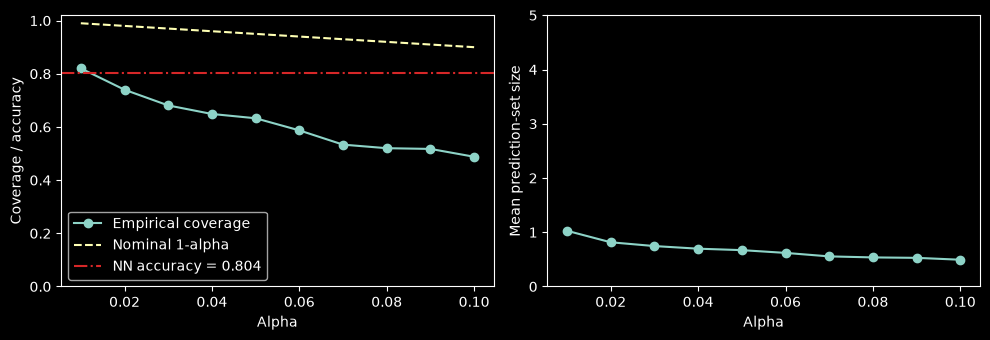

In [24]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
levels = [row["alpha"] for row in alpha_results]
axes[0].plot(levels, [row["coverage"] for row in alpha_results], "o-", label="Empirical coverage")
axes[0].plot(levels, [1 - a for a in levels], "--", label="Nominal 1-alpha")
nn_accuracy = float((p_test.argmax(1) == y_test).mean())
axes[0].axhline(nn_accuracy, color="tab:red", linestyle="-.",
               label=f"NN accuracy = {nn_accuracy:.3f}")
axes[0].set(xlabel="Alpha", ylabel="Coverage / accuracy", ylim=(0, 1.02))
axes[0].legend()
axes[1].plot(levels, [row["mean_set_size"] for row in alpha_results], "o-")
axes[1].set(xlabel="Alpha", ylabel="Mean prediction-set size", ylim=(0, len(class_names)))
fig.tight_layout()
fig.savefig(cp_dir / "coverage_set_size.png", dpi=150)
plt.show()

In [25]:
# Training's W&B run has finished; record evaluation as a separate, linked run.
if monitor_config["enabled"]:
    import wandb
    cp_run = wandb.init(project=monitor_config["project"], entity=monitor_config.get("entity"),
                    mode=monitor_config["mode"], dir=str(cp_dir), settings={"quiet": True},
                    name=cp_dir.name, group=run_dir.name, job_type="conformal",
                    config={k: v for k, v in cp_config.items() if k not in ("checkpoint", "split_manifest")})
    try:
        with cp_run:
            cp_run.summary.update({f"test/{k}": v for k, v in metrics.items() if v is not None})
            cp_run.summary["score_validation_accuracy"] = score_validation_accuracy
            cp_run.define_metric("alpha")
            cp_run.define_metric("sweep/*", step_metric="alpha")
            for row in alpha_results:
                cp_run.log({"alpha": row["alpha"], **{f"sweep/{k}": v for k, v in row.items() if k != "alpha" and v is not None}})
            cp_run.log({"per_class": wandb.Table(
                columns=["class", "samples", "coverage", "mean_set_size"],
                data=[[name, row["samples"], row.get("coverage"), row.get("mean_set_size")]
                      for name, row in per_class.items()]),
                "coverage_set_size": wandb.Image(str(cp_dir / "coverage_set_size.png"))})
    except Exception as error:
        import warnings
        warnings.warn(f"W&B evaluation logging failed; local results are saved: {error}", RuntimeWarning)


## Compare embedding projections

Load saved train/validation/calibration/test embeddings once and compare t-SNE, Isomap, Spectral Embedding and metric MDS using the same samples, scale, colors and three views (task, domain, split). No retraining or KDE fitting is needed. Set `viz_dir` to the current `cp_dir` or an existing `conformal-*` directory; the sampling seed, per-split cap and method settings are below. Each method saves its PNG and coordinates/metadata NPZ in that directory.

- t-SNE emphasizes local neighborhoods; cluster gaps and sizes do not directly measure original distances or densities.
- Isomap approximates distances along a nearest-neighbor graph.
- Spectral Embedding emphasizes neighborhood connections.
- Metric MDS tries to preserve pairwise Euclidean distances.

Adjust `map_neighbors` for the graph methods. Disconnected-graph warnings matter: relative positions of disconnected groups are unreliable, and Isomap may add connections. Axes and scales are method-specific; no projection alone proves invariance. MDS and Isomap use pairwise-distance matrices, so reduce `viz_max_per_split` if computation is too expensive. Change method parameters directly in `embedding_maps`. Increase MDS `max_iter` when MDS reaches its iteration limit.


Computing t-SNE for 2538 samples...


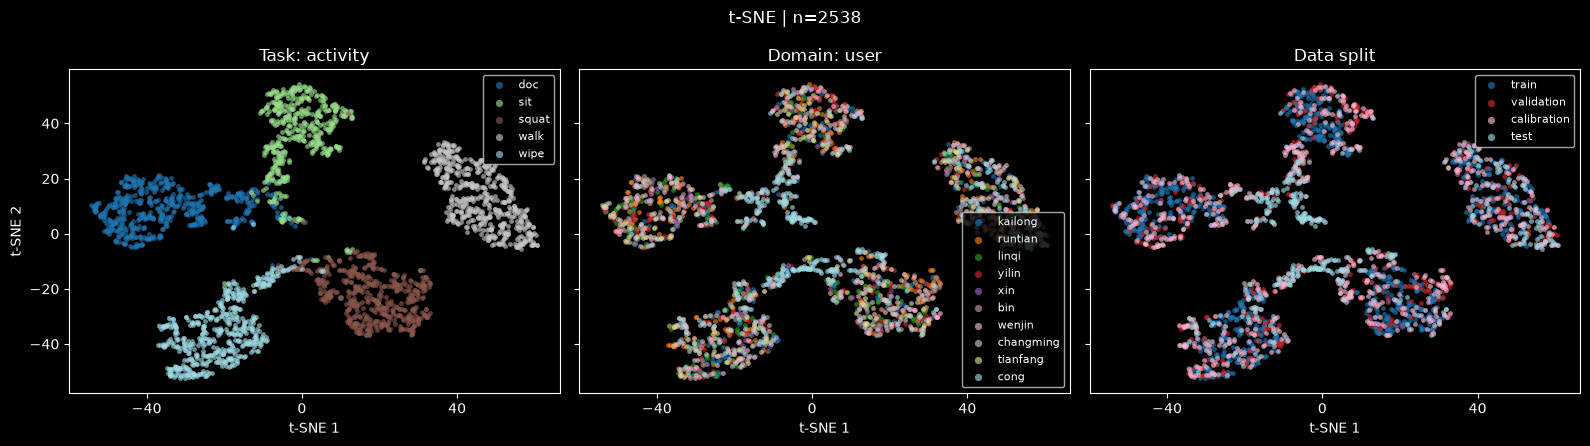

Saved: /home/kailong/Desktop/WiFi_Conformal_Prediction/python/runs/20261006T013602985790Z/conformal-20261006T074807439442Z/embedding_tsne.png
Computing Metric MDS for 2538 samples...


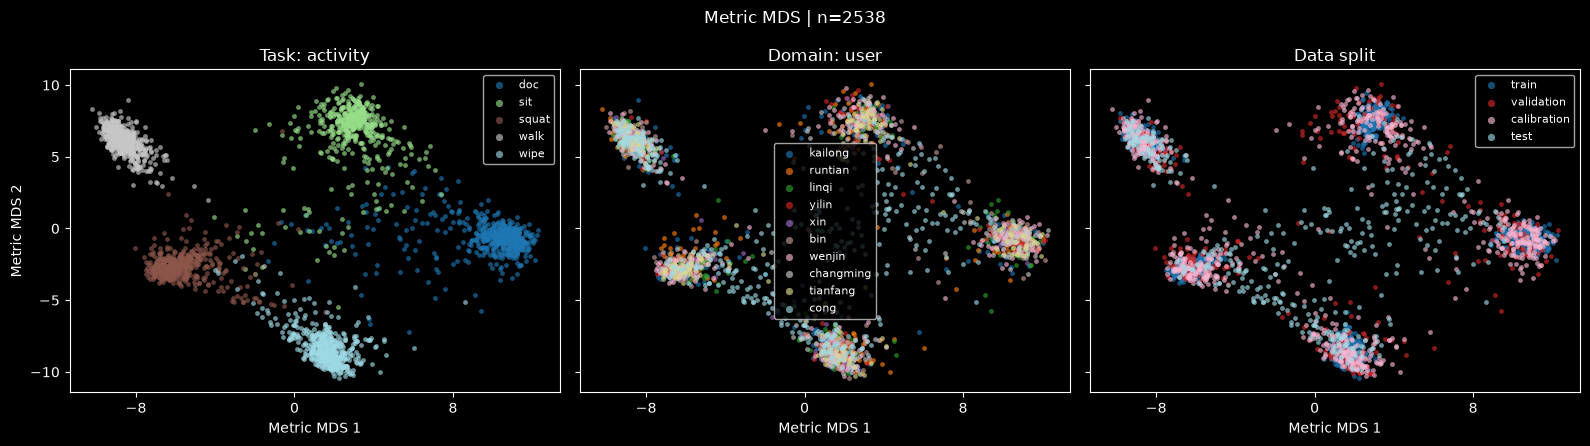

Saved: /home/kailong/Desktop/WiFi_Conformal_Prediction/python/runs/20261006T013602985790Z/conformal-20261006T074807439442Z/embedding_mds.png


In [26]:
from pathlib import Path
import json
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE, Isomap, SpectralEmbedding, MDS
from matplotlib.ticker import MaxNLocator

viz_dir = Path(cp_dir)  # Or Path("runs/<run>/conformal-<timestamp>")
viz_seed = 42
viz_max_per_split = 1000  # Random subset per split; None keeps every segment.

viz_manifest = json.loads((viz_dir.parent / "experiment.json").read_text())
viz_domain_key = viz_manifest["data"]["domain_key"]
viz_rng = np.random.default_rng(viz_seed)
viz_embeddings, viz_labels, viz_domains, viz_splits = [], [], [], []
viz_recordings, viz_segments = [], []
for split in ("train", "validation", "calibration", "test"):
    with np.load(viz_dir / f"{split}_embeddings.npz") as arrays:
        selected = np.arange(len(arrays["labels"]))
        if viz_max_per_split is not None and len(selected) > viz_max_per_split:
            selected = np.sort(viz_rng.choice(selected, viz_max_per_split, replace=False))
        # Saved split pairs have the same row order as the embedding exports.
        pairs = np.asarray(viz_manifest["splits"][split])[selected]
        viz_embeddings.append(arrays["embeddings"][selected])
        viz_labels.extend(viz_manifest["class_names"][label] for label in arrays["labels"][selected])
        viz_domains.extend(viz_manifest["recordings"][i]["metadata"][viz_domain_key]
                            for i, j in pairs)
        viz_splits.extend([split] * len(selected))
        viz_recordings.extend(arrays["recording"][selected])
        viz_segments.extend(arrays["segment_index"][selected])

viz_embeddings = np.concatenate(viz_embeddings)
viz_labels, viz_domains, viz_splits = map(np.asarray, (viz_labels, viz_domains, viz_splits))

map_neighbors = min(30, len(viz_embeddings) - 1)

embedding_maps = {
    "tsne": TSNE(n_components=2, perplexity=min(30.0, len(viz_embeddings) - 1), init="pca", learning_rate="auto", random_state=viz_seed),
    # "isomap": Isomap(n_components=2, n_neighbors=map_neighbors),
    # "spectral": SpectralEmbedding(n_components=2, n_neighbors=map_neighbors,
    #                               affinity="nearest_neighbors", random_state=viz_seed),
    "mds": MDS(n_components=2, n_init=4, max_iter=300,
               init="random", eps=1e-6, random_state=viz_seed),
}
map_titles = {"tsne": "t-SNE", "isomap": "Isomap", "spectral": "Spectral Embedding", "mds": "Metric MDS"}
for name, mapper in embedding_maps.items():
    print(f"Computing {map_titles[name]} for {len(viz_embeddings)} samples...", flush=True)
    coordinates = mapper.fit_transform(viz_embeddings)
    if name == "mds" and mapper.n_iter_ >= mapper.max_iter:
        print("MDS reached max_iter; increase max_iter in embedding_maps to check convergence.")
    fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), sharex=True, sharey=True)
    for ax, values, title in zip(axes, (viz_labels, viz_domains, viz_splits),
                                (f"Task: {viz_manifest['task']}", f"Domain: {viz_domain_key}", "Data split")):
        categories = list(dict.fromkeys(values))
        colors = plt.get_cmap("tab20", len(categories))
        for i, category in enumerate(categories):
            selected = values == category
            ax.scatter(*coordinates[selected].T, s=12, alpha=0.65,
                       color=colors(i), label=category, linewidths=0)
        ax.set(title=title, xlabel=f"{map_titles[name]} 1")
        ax.xaxis.set_major_locator(MaxNLocator(4))
        ax.legend(fontsize=8, markerscale=1.5)
    axes[0].set_ylabel(f"{map_titles[name]} 2")
    fig.suptitle(f"{map_titles[name]} | n={len(viz_embeddings)}")
    fig.tight_layout()
    fig.savefig(viz_dir / f"embedding_{name}.png", dpi=180)
    np.savez_compressed(viz_dir / f"embedding_{name}.npz", coordinates=coordinates,
                        labels=viz_labels, domains=viz_domains, splits=viz_splits,
                        recording=np.asarray(viz_recordings), segment_index=np.asarray(viz_segments),
                        parameters=json.dumps(mapper.get_params()), seed=viz_seed,
                        max_per_split=-1 if viz_max_per_split is None else viz_max_per_split)
    plt.show()
    print("Saved:", viz_dir / f"embedding_{name}.png")


## Randomized APS comparison (no retraining)

Run this section after prediction exports. It reads saved probabilities from `aps_source_dir`, so the training and embedding plots do not need to run again. After restarting the kernel, set this path explicitly and run the notebook import/path setup first.

APS sorts classes by decreasing probability and uses `sum(probabilities before candidate) + U * candidate_probability`. One independent uniform draw per sample is shared across its candidate labels; stable class-index ordering resolves ties. Calibration and test use independent random streams. Draws stay fixed across the alpha sweep and reruns with the same seed. No forced nonempty sets are added.

Compare the saved CP result with unweighted APS and, when available, APS using the exact saved calibration/test weights. NN accuracy always uses the original softmax argmax. Results are saved under a separate `aps-seed-*` directory; the original CP artifacts are preserved. This is one randomized realization, not evidence of guaranteed coverage under domain shift.


In [ ]:
from pathlib import Path
import json
import numpy as np
import matplotlib.pyplot as plt
from step05_calibration.calibrate import RankCalibrator, WeightedRankCalibrator
from step06_prediction.predict import prediction_sets
from step07_evaluation.evaluate import evaluate

aps_source_dir = Path(cp_dir)  # Or Path("runs/<run>/conformal-<timestamp>")
aps_seed = 42
aps_config = json.loads((aps_source_dir / "config.json").read_text())
aps_levels = sorted(set(aps_config["alpha_grid"] + [aps_config["calibration"]["alpha"]]))
with np.load(aps_source_dir / "calibration_embeddings.npz") as arrays:
    aps_cal_prob = arrays["probabilities"].copy()
    aps_cal_labels = arrays["labels"].copy()
with np.load(aps_source_dir / "test_embeddings.npz") as arrays:
    aps_test_prob = arrays["probabilities"].copy()
    aps_test_labels = arrays["labels"].copy()
with np.load(aps_source_dir / "predictions.npz") as arrays:
    if not np.array_equal(arrays["labels"], aps_test_labels):
        raise ValueError("Saved prediction and test export labels do not match")
    if not np.array_equal(arrays["cnn_probabilities"], aps_test_prob):
        raise ValueError("Saved prediction and test export probabilities do not match")
    aps_original_p_values = arrays["p_values"].copy()


def randomized_aps_scores(probabilities, rng):
    probabilities = np.asarray(probabilities, dtype=np.float64)
    if (probabilities.ndim != 2 or not len(probabilities) or probabilities.shape[1] < 2
            or not np.isfinite(probabilities).all() or (probabilities < 0).any()
            or not np.allclose(probabilities.sum(axis=1), 1, atol=1e-6, rtol=1e-5)):
        raise ValueError("APS requires finite, nonnegative class probabilities summing to one")
    probabilities = probabilities / probabilities.sum(axis=1, keepdims=True)
    order = np.argsort(-probabilities, axis=1, kind="stable")
    ranked = np.take_along_axis(probabilities, order, axis=1)
    uniform = rng.random((len(probabilities), 1))
    cumulative_before = np.cumsum(ranked, axis=1) - ranked
    ranked_scores = cumulative_before + uniform * ranked
    scores = np.empty_like(ranked_scores)
    np.put_along_axis(scores, order, ranked_scores, axis=1)
    return scores, uniform[:, 0]


aps_streams = np.random.SeedSequence(aps_seed).spawn(2)
aps_cal_scores, aps_cal_uniform = randomized_aps_scores(aps_cal_prob, np.random.default_rng(aps_streams[0]))
aps_test_scores, aps_test_uniform = randomized_aps_scores(aps_test_prob, np.random.default_rng(aps_streams[1]))
aps_point_predictions = aps_test_prob.argmax(axis=1)
aps_nn_accuracy = float((aps_point_predictions == aps_test_labels).mean())
aps_original_name = "Existing " + aps_config["score"]["kind"] + (" weighted CP" if aps_config["calibration"]["weighted_cp"] else " CP")
aps_p_values = {aps_original_name: aps_original_p_values}
aps_plain_calibrator = RankCalibrator().fit(aps_cal_scores, aps_cal_labels)
aps_p_values["APS unweighted"] = aps_plain_calibrator.p_values(aps_test_scores)
if aps_config["calibration"]["weighted_cp"]:
    with np.load(aps_source_dir / "calibration_weights.npz") as arrays:
        aps_cal_weights = arrays["weights"].copy()
    with np.load(aps_source_dir / "test_weights.npz") as arrays:
        aps_test_weights = arrays["weights"].copy()
    aps_weighted_calibrator = WeightedRankCalibrator().fit(aps_cal_scores, aps_cal_labels, aps_cal_weights)
    aps_p_values["APS weighted"] = aps_weighted_calibrator.p_values(aps_test_scores, aps_test_weights)

aps_results = {}
for aps_name, aps_values in aps_p_values.items():
    aps_rows = []
    for aps_alpha in aps_levels:
        aps_sets = prediction_sets(aps_values, aps_alpha)
        aps_row = evaluate(aps_test_labels, aps_sets, aps_point_predictions)
        aps_rows.append({"alpha": aps_alpha, "nominal_coverage": 1 - aps_alpha, **aps_row})
    aps_results[aps_name] = aps_rows

aps_output_dir = aps_source_dir / f"aps-seed-{aps_seed}"
aps_output_dir.mkdir(exist_ok=True)
(aps_output_dir / "metrics.json").write_text(json.dumps({
    "seed": aps_seed, "source": str(aps_source_dir.resolve()),
    "checkpoint_sha256": aps_config["checkpoint_sha256"],
    "randomization": "Independent sample uniforms shared across candidate labels; stable class-index ties",
    "nn_accuracy": aps_nn_accuracy, "alpha_sweeps": aps_results,
}, indent=2, allow_nan=False))
np.savez_compressed(aps_output_dir / "scores_predictions.npz",
                    calibration_scores=aps_cal_scores, test_scores=aps_test_scores,
                    calibration_uniform=aps_cal_uniform, test_uniform=aps_test_uniform,
                    calibration_labels=aps_cal_labels, test_labels=aps_test_labels,
                    class_names=np.asarray(aps_config["class_names"]),
                    **{name.replace(" ", "_"): values for name, values in aps_p_values.items()})

aps_fig, aps_axes = plt.subplots(1, 2, figsize=(12, 4))
for aps_name, aps_rows in aps_results.items():
    aps_axes[0].plot(aps_levels, [row["coverage"] for row in aps_rows], "o-", label=aps_name)
    aps_axes[1].plot(aps_levels, [row["mean_set_size"] for row in aps_rows], "o-", label=aps_name)
aps_axes[0].plot(aps_levels, 1 - np.asarray(aps_levels), "--", color="gray", label="Nominal 1-alpha")
aps_axes[0].axhline(aps_nn_accuracy, color="tab:red", linestyle="-.", label=f"NN accuracy = {aps_nn_accuracy:.3f}")
aps_axes[0].set(xlabel="Alpha", ylabel="Coverage / accuracy", ylim=(0, 1.02))
aps_axes[1].set(xlabel="Alpha", ylabel="Mean prediction-set size", ylim=(0, len(aps_config["class_names"])))
for aps_ax in aps_axes:
    aps_ax.legend(fontsize=8)
aps_fig.suptitle(f"Randomized APS comparison | seed={aps_seed}")
aps_fig.tight_layout()
aps_fig.savefig(aps_output_dir / "coverage_set_size.png", dpi=150)
plt.show()
for aps_name, aps_rows in aps_results.items():
    aps_row = next(row for row in aps_rows if row["alpha"] == aps_config["calibration"]["alpha"])
    print(f"{aps_name}: alpha={aps_row['alpha']:.2f}, coverage={aps_row['coverage']:.3f}, "
          f"mean size={aps_row['mean_set_size']:.3f}, empty={aps_row['empty_fraction']:.3f}")
print("APS results:", aps_output_dir)
